In [7]:
# Libraries and configurations
import sys
from pathlib import Path
import json

# PyTorch
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models
from torchvision import transforms
from torchinfo import summary

# Visualization and analysis
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm
import pandas as pd
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import PIL

# Adds the project root to the path
project_root = Path.cwd().parent
sys.path.insert(0, str(project_root))

from config import (
    get_dataset_paths
)

from src.dataset import DataModuleParasite

### Configurações gerais

In [8]:
# Functions for training and evaluation

class AverageMeter:
    def __init__(self):
        self.reset()

    def reset(self):
        self.val = 0
        self.avg = 0
        self.sum = 0
        self.count = 0

    def update(self, val, n=1):
        self.val = val
        self.sum += val * n
        self.count += n
        self.avg = self.sum / self.count

def train(model, train_loader, criterion, optimizer, device):
    model.train()
    
    train_loss_avg = AverageMeter()
    train_acc_avg = AverageMeter()

    for input, label in tqdm(train_loader, desc="Training", leave=False):
        input, label = input.to(device), label.to(device)

        # Forward
        optimizer.zero_grad()
        outputs = model(input)
        loss = criterion(outputs, label)

        # Backward
        loss.backward()
        optimizer.step()
        
        # Predictions
        _, preds = torch.max(outputs, 1)
        
        # Metrics for batch
        batch_acc = (preds == label).sum().item() / label.size(0)

        train_loss_avg.update(loss.item(), label.size(0))
        train_acc_avg.update(batch_acc, label.size(0))

    return train_loss_avg.avg, train_acc_avg.avg

def evaluate(model, val_loader, criterion, device):
    model.eval()
    
    val_loss_avg = AverageMeter()
    val_acc_avg = AverageMeter()
    
    with torch.no_grad():
        for input, label in tqdm(val_loader, desc="Validation", leave=False):
            input, label = input.to(device), label.to(device)

            # Forward
            outputs = model(input)
            loss = criterion(outputs, label)

            # Predictions
            _, preds = torch.max(outputs, 1)

            # Metrics for batch
            batch_acc = (preds == label).sum().item() / label.size(0)

            val_loss_avg.update(loss.item(), label.size(0))
            val_acc_avg.update(batch_acc, label.size(0))

    return val_loss_avg.avg, val_acc_avg.avg

### Eggs 

In [3]:
# Configuration for Egg Dataset
CONFIG_EGG = {
    'dataset_name': 'eggs',
    'split': 1,
    'percentage': [5, 25, 50, 75, 100],
    'num_classes': 9,
    'batch_size': 16,
    'num_workers': 4,
    'image_size': 200,
    'lr': 1e-4,
    'num_epochs': 100,
    'device': 'cuda' if torch.cuda.is_available() else 'cpu'
}

# Create dataloaders
dataloaders_perc = {}

transforms_egg = transforms.Compose([
    transforms.Resize((CONFIG_EGG['image_size'], CONFIG_EGG['image_size'])),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

for perc in CONFIG_EGG['percentage']:
    data_module = DataModuleParasite(
        dataset_name=CONFIG_EGG['dataset_name'],
        split=CONFIG_EGG['split'],
        percentage=perc,
        batch_size=CONFIG_EGG['batch_size'],
        num_workers=CONFIG_EGG['num_workers'],
        transform=transforms_egg
    )
    data_module.setup()
    dataloaders_perc[perc] = {
        'train': data_module.train_dataloader(),
        'val': data_module.val_dataloader(),
        'test': data_module.test_dataloader()
    }

In [ ]:
# Model
vgg16_model_pretrained = models.vgg16(weights=models.VGG16_Weights.IMAGENET1K_V1)
vgg16_model_pretrained.classifier[6] = nn.Linear(in_features=4096, out_features=CONFIG_EGG['num_classes'])
vgg16_model_pretrained = vgg16_model_pretrained.to(CONFIG_EGG['device'])

total_params = sum(p.numel() for p in vgg16_model_pretrained.parameters())
trainable_params = sum(p.numel() for p in vgg16_model_pretrained.parameters() if p.requires_grad)

# print(f"Total parameters: {total_params}")
# print(f"Trainable parameters: {trainable_params}")
# print(summary(vgg16_model_pretrained, input_size=(1, 3, 224, 224)))

# Loss , Optimizer and Scheduler
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(vgg16_model_pretrained.parameters(), lr=CONFIG_EGG['lr'])
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.1)

In [7]:
# Training loop
historic_perc = {} 

for perc in CONFIG_EGG['percentage']:
    patience = 20
    best_val_loss = float('inf')
    epochs_no_improve = 0
    
    best_val_acc = 0.0
    historic_perc[perc] = {
        'train_loss': [],
        'train_acc': [],
        'val_loss': [],
        'val_acc': []
    }
    
    for epoch in tqdm(range(CONFIG_EGG['num_epochs']), desc=f"Percentage {perc}%", leave=False):
        
        train_loss, train_acc = train(vgg16_model_pretrained, dataloaders_perc[perc]['train'], criterion, optimizer, CONFIG_EGG['device'])

        val_loss, val_acc = evaluate(vgg16_model_pretrained, dataloaders_perc[perc]['val'], criterion, CONFIG_EGG['device'])

        historic_perc[perc]['train_loss'].append(train_loss)
        historic_perc[perc]['train_acc'].append(train_acc)
        historic_perc[perc]['val_loss'].append(val_loss)
        historic_perc[perc]['val_acc'].append(val_acc)

        # Early Stopping
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1

        if epochs_no_improve == patience:
            print(f"Early stopping triggered at epoch {epoch}")
            break

        # Save the best model
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(vgg16_model_pretrained.state_dict(), f'vgg16_egg_best_acc_perc_{perc}_split{CONFIG_EGG["split"]}.pth')

        scheduler.step()

Early stopping triggered at epoch 22


Early stopping triggered at epoch 90


Early stopping triggered at epoch 20


Early stopping triggered at epoch 20


Early stopping triggered at epoch 20


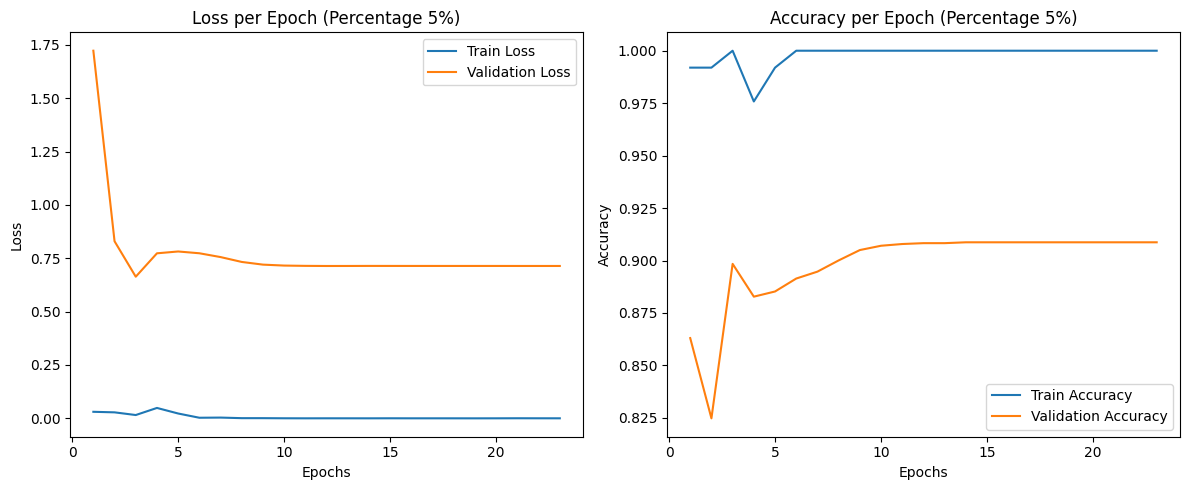

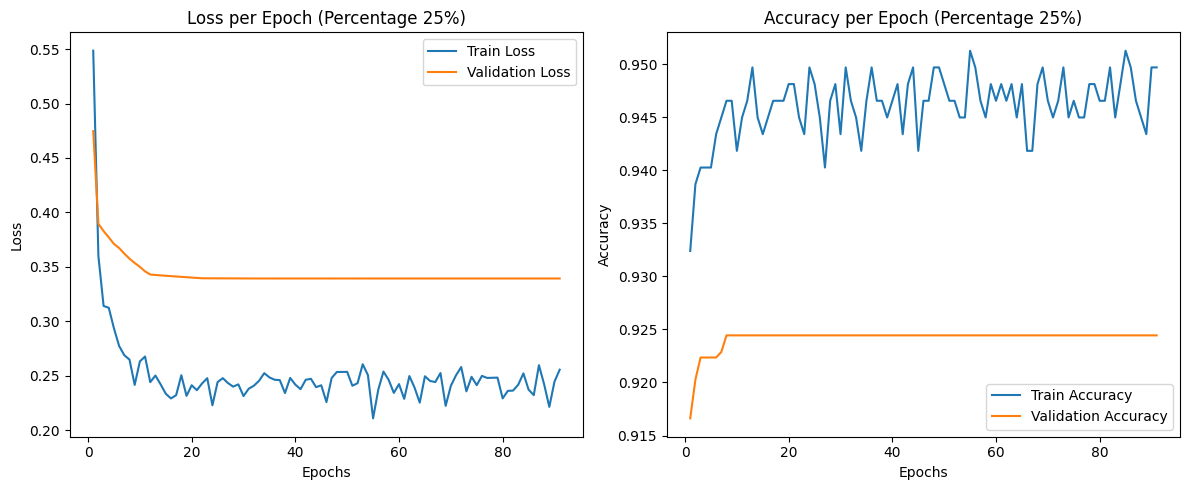

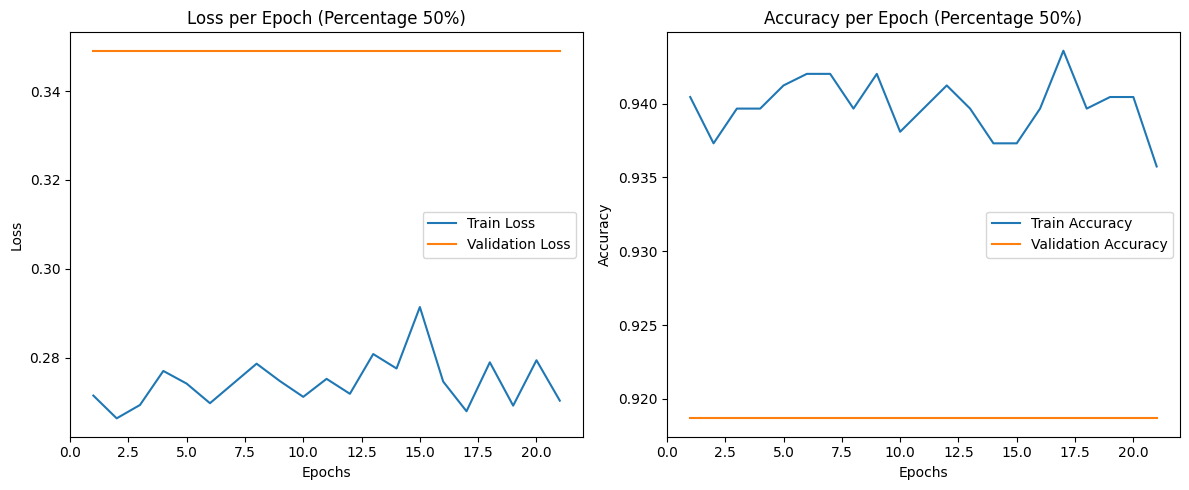

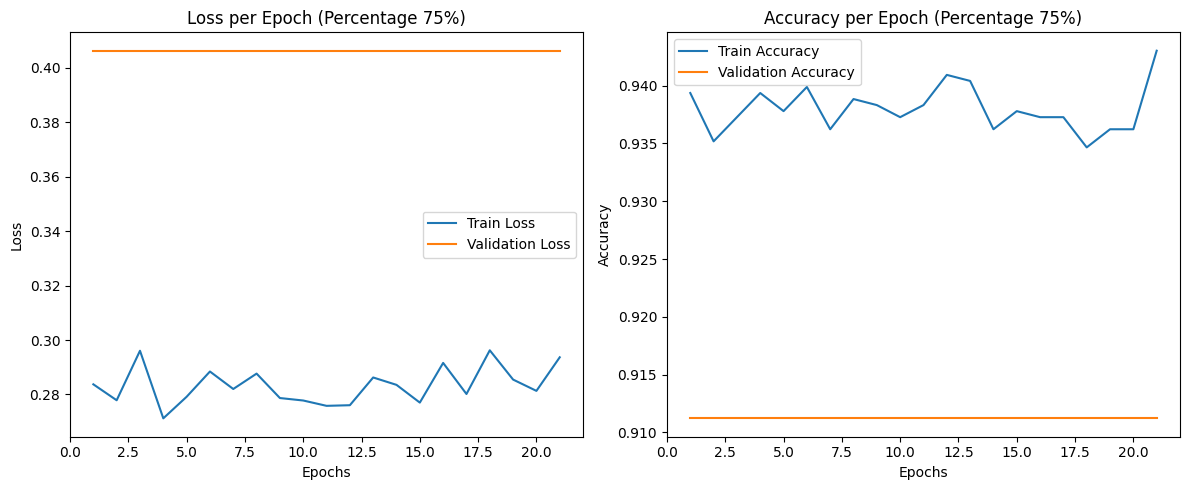

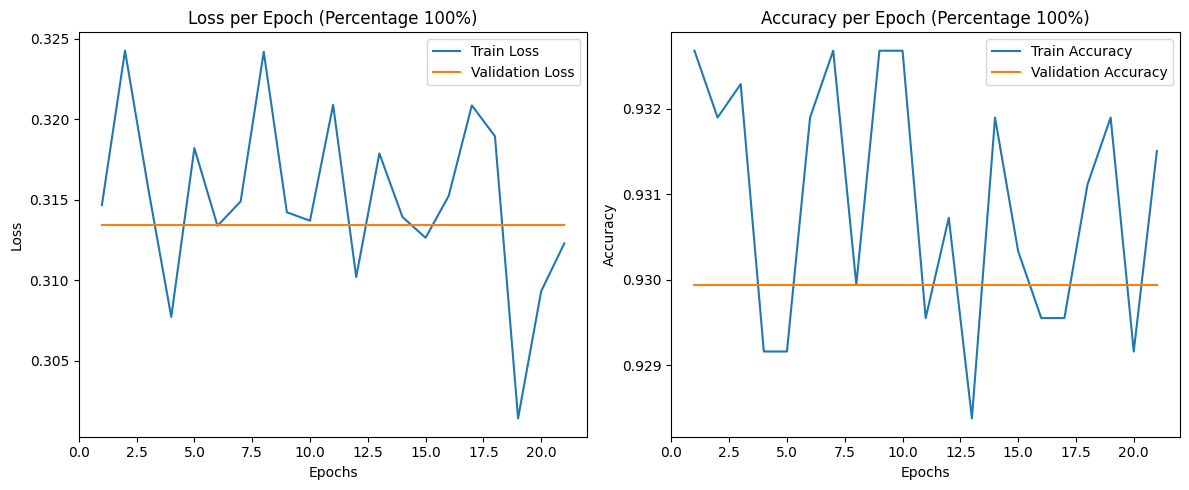

In [8]:
# Loss and Accuracy plots
for perc in CONFIG_EGG['percentage']:
    epochs = range(1, len(historic_perc[perc]['train_loss']) + 1)

    plt.figure(figsize=(12, 5))

    # Loss plot
    plt.subplot(1, 2, 1)
    plt.plot(epochs, historic_perc[perc]['train_loss'], label='Train Loss')
    plt.plot(epochs, historic_perc[perc]['val_loss'], label='Validation Loss')
    plt.title(f'Loss per Epoch (Percentage {perc}%)')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

    # Accuracy plot
    plt.subplot(1, 2, 2)
    plt.plot(epochs, historic_perc[perc]['train_acc'], label='Train Accuracy')
    plt.plot(epochs, historic_perc[perc]['val_acc'], label='Validation Accuracy')
    plt.title(f'Accuracy per Epoch (Percentage {perc}%)')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.tight_layout()
    plt.show()
   

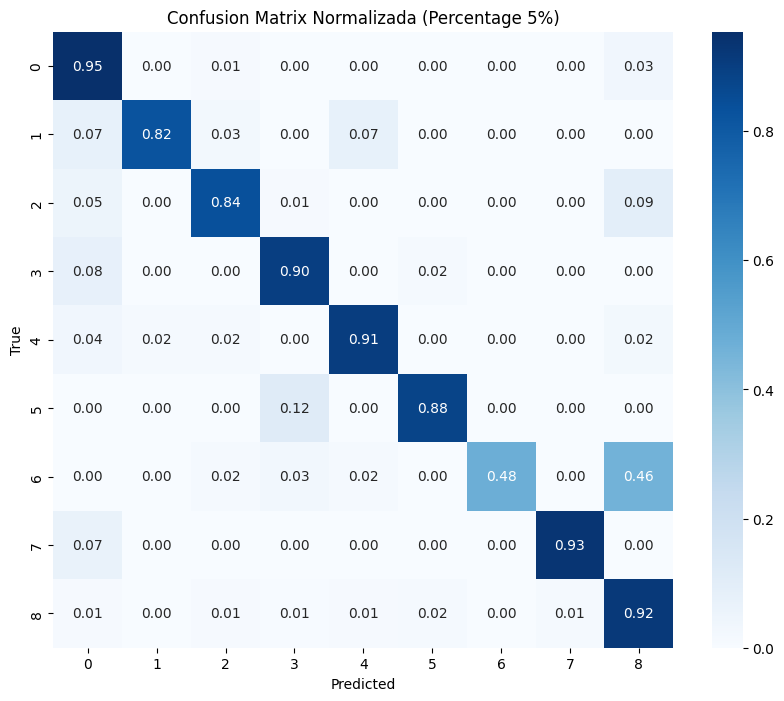

Kappa (Cohen) (Percentage 5%): 0.8338
Classification Report (Percentage 5%):
              precision    recall  f1-score   support

           0       0.77      0.95      0.85       174
           1       0.92      0.82      0.87        40
           2       0.68      0.84      0.75        74
           3       0.60      0.90      0.72        61
           4       0.85      0.91      0.88       169
           5       0.86      0.88      0.87       188
           6       0.97      0.48      0.64        61
           7       0.81      0.93      0.87       118
           8       0.97      0.92      0.95      1672

    accuracy                           0.90      2557
   macro avg       0.83      0.85      0.82      2557
weighted avg       0.92      0.90      0.91      2557



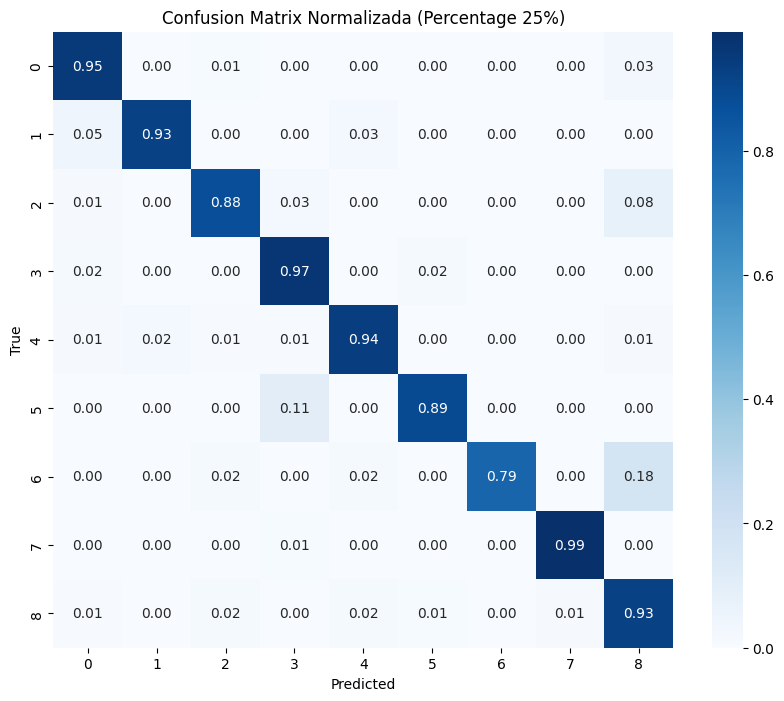

Kappa (Cohen) (Percentage 25%): 0.8707
Classification Report (Percentage 25%):
              precision    recall  f1-score   support

           0       0.91      0.95      0.93       174
           1       0.90      0.93      0.91        40
           2       0.66      0.88      0.75        74
           3       0.67      0.97      0.79        61
           4       0.83      0.94      0.88       169
           5       0.89      0.89      0.89       188
           6       0.91      0.79      0.84        61
           7       0.83      0.99      0.90       118
           8       0.98      0.93      0.95      1672

    accuracy                           0.93      2557
   macro avg       0.84      0.92      0.87      2557
weighted avg       0.93      0.93      0.93      2557



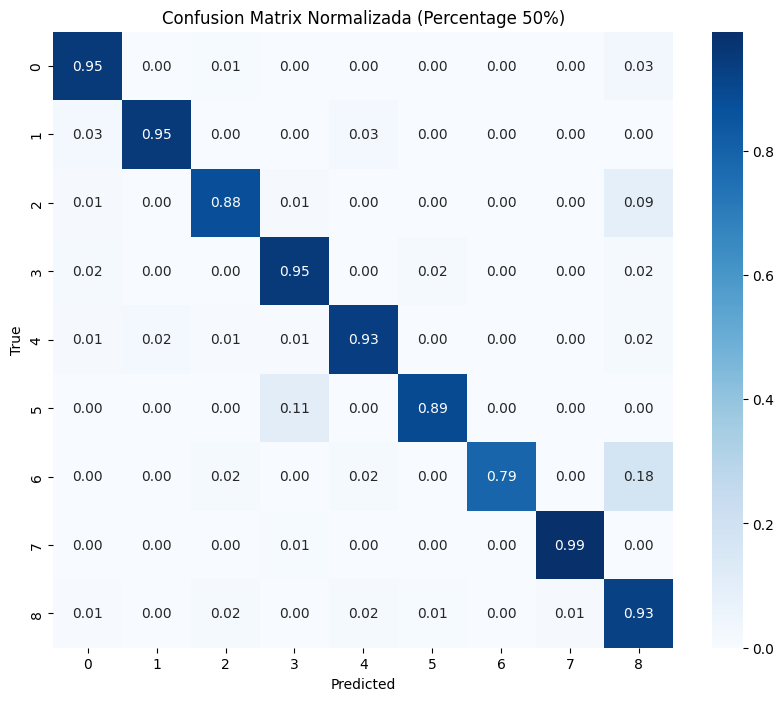

Kappa (Cohen) (Percentage 50%): 0.8711
Classification Report (Percentage 50%):
              precision    recall  f1-score   support

           0       0.91      0.95      0.93       174
           1       0.90      0.95      0.93        40
           2       0.66      0.88      0.75        74
           3       0.67      0.95      0.79        61
           4       0.84      0.93      0.88       169
           5       0.89      0.89      0.89       188
           6       0.91      0.79      0.84        61
           7       0.83      0.99      0.90       118
           8       0.98      0.93      0.95      1672

    accuracy                           0.93      2557
   macro avg       0.84      0.92      0.88      2557
weighted avg       0.93      0.93      0.93      2557



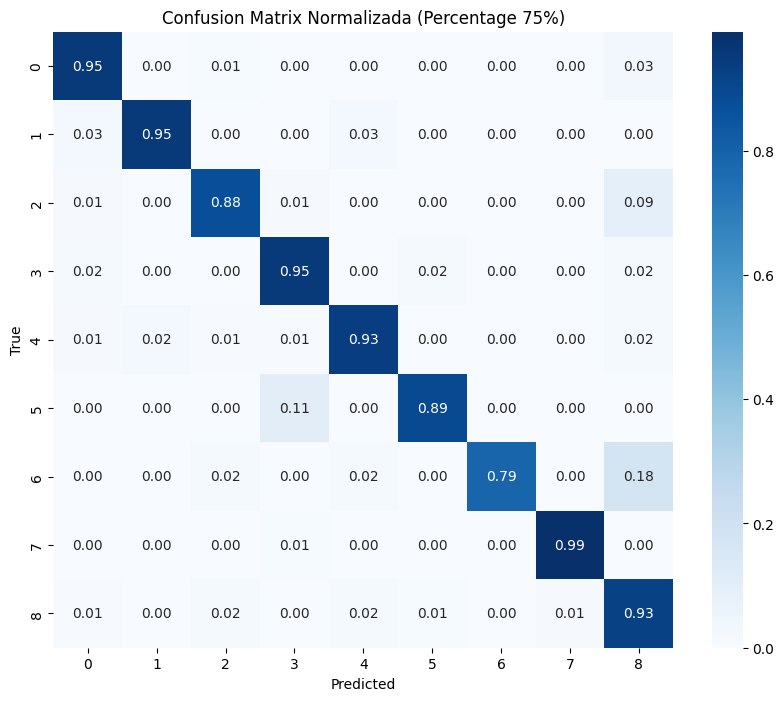

Kappa (Cohen) (Percentage 75%): 0.8711
Classification Report (Percentage 75%):
              precision    recall  f1-score   support

           0       0.91      0.95      0.93       174
           1       0.90      0.95      0.93        40
           2       0.66      0.88      0.75        74
           3       0.67      0.95      0.79        61
           4       0.84      0.93      0.88       169
           5       0.89      0.89      0.89       188
           6       0.91      0.79      0.84        61
           7       0.83      0.99      0.90       118
           8       0.98      0.93      0.95      1672

    accuracy                           0.93      2557
   macro avg       0.84      0.92      0.88      2557
weighted avg       0.93      0.93      0.93      2557



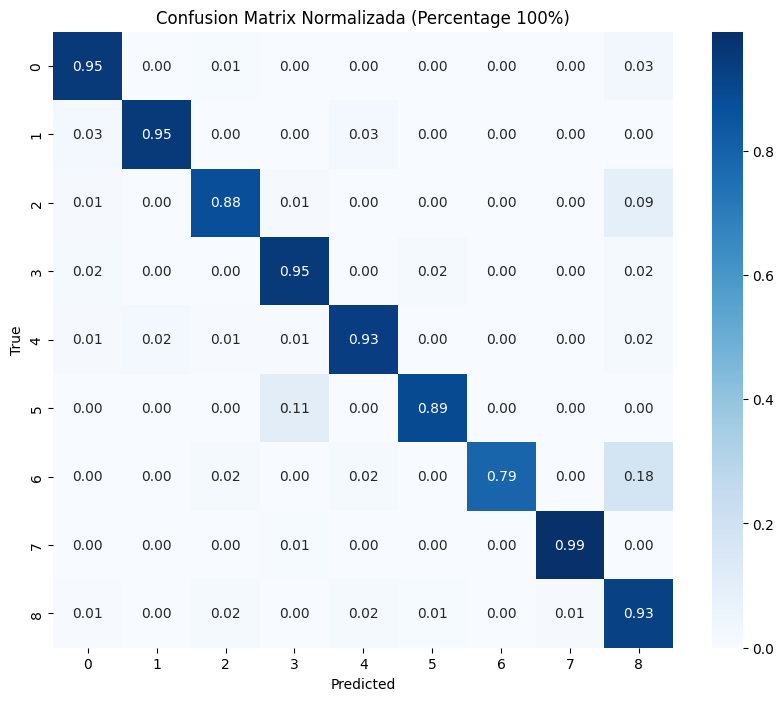

Kappa (Cohen) (Percentage 100%): 0.8711
Classification Report (Percentage 100%):
              precision    recall  f1-score   support

           0       0.91      0.95      0.93       174
           1       0.90      0.95      0.93        40
           2       0.66      0.88      0.75        74
           3       0.67      0.95      0.79        61
           4       0.84      0.93      0.88       169
           5       0.89      0.89      0.89       188
           6       0.91      0.79      0.84        61
           7       0.83      0.99      0.90       118
           8       0.98      0.93      0.95      1672

    accuracy                           0.93      2557
   macro avg       0.84      0.92      0.88      2557
weighted avg       0.93      0.93      0.93      2557



In [6]:
from sklearn.metrics import cohen_kappa_score

# Avaliaton on test set
for perc in CONFIG_EGG['percentage']:
    # Load the best model
    model = models.vgg16(weights=models.VGG16_Weights.IMAGENET1K_V1)
    model.classifier[6] = nn.Linear(in_features=4096, out_features=CONFIG_EGG['num_classes'])
    model.load_state_dict(torch.load(f'vgg16_egg_best_acc_perc_{perc}_split{CONFIG_EGG["split"]}.pth'))
    model = model.to(CONFIG_EGG['device'])
    model.eval()

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for input, label in tqdm(dataloaders_perc[perc]['test'], desc=f"Testing Percentage {perc}%", leave=False):
            input, label = input.to(CONFIG_EGG['device']), label.to(CONFIG_EGG['device'])

            outputs = model(input)
            _, preds = torch.max(outputs, 1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(label.cpu().numpy())

    # Confusion Matrix (normalizada por linha - recall por classe)
    cm = confusion_matrix(all_labels, all_preds)
    cm_norm = cm.astype('float') / cm.sum(axis=1)[:, None]  # normaliza por verdadeiro (linhas)
    # evita NaNs quando alguma linha tem soma 0
    cm_norm = np.nan_to_num(cm_norm)

    plt.figure(figsize=(10, 8))
    sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
                xticklabels=list(range(CONFIG_EGG['num_classes'])),
                yticklabels=list(range(CONFIG_EGG['num_classes'])))
    plt.title(f'Confusion Matrix Normalizada (Percentage {perc}%)')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.show()

    # Kappa
    kappa = cohen_kappa_score(all_labels, all_preds)
    print(f'Kappa (Cohen) (Percentage {perc}%): {kappa:.4f}')

    # Classification Report
    report = classification_report(all_labels, all_preds)
    print(f'Classification Report (Percentage {perc}%):\n{report}')

### Cistos

In [ ]:
# Configuration for Cistos Dataset
CONFIG_CISTOS = {
    'dataset_name': 'cistos',
    'split': 1,
    'percentage': [5, 25, 50, 75, 100],
    'num_classes': 7,
    'batch_size': 16,
    'num_workers': 4,
    'image_size': 200,
    'lr': 1e-4,
    'num_epochs': 100,
    'device': 'cuda' if torch.cuda.is_available() else 'cpu'
}

# Create dataloaders
dataloaders_perc = {}

transforms_cistos = transforms.Compose([
    transforms.Resize((CONFIG_CISTOS['image_size'], CONFIG_CISTOS['image_size'])),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

for perc in CONFIG_CISTOS['percentage']:
    data_module = DataModuleParasite(
        dataset_name=CONFIG_CISTOS['dataset_name'],
        split=CONFIG_CISTOS['split'],
        percentage=perc,
        batch_size=CONFIG_CISTOS['batch_size'],
        num_workers=CONFIG_CISTOS['num_workers'],
        transform=transforms_cistos
    )
    data_module.setup()
    dataloaders_perc[perc] = {
        'train': data_module.train_dataloader(),
        'val': data_module.val_dataloader(),
        'test': data_module.test_dataloader()
    }
    
# Model
vgg16_model_pretrained = models.vgg16(weights=models.VGG16_Weights.IMAGENET1K_V1)
vgg16_model_pretrained.classifier[6] = nn.Linear(in_features=4096, out_features=CONFIG_CISTOS['num_classes'])
vgg16_model_pretrained = vgg16_model_pretrained.to(CONFIG_CISTOS['device'])

total_params = sum(p.numel() for p in vgg16_model_pretrained.parameters())
trainable_params = sum(p.numel() for p in vgg16_model_pretrained.parameters() if p.requires_grad)

# print(f"Total parameters: {total_params}")
# print(f"Trainable parameters: {trainable_params}")
# print(summary(vgg16_model_pretrained, input_size=(1, 3, 224, 224)))

# Loss , Optimizer and Scheduler
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(vgg16_model_pretrained.parameters(), lr=CONFIG_CISTOS['lr'])
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.1)

In [ ]:
# Training loop
historic_perc = {} 

for perc in CONFIG_CISTOS['percentage']:
    patience = 20
    best_val_loss = float('inf')
    epochs_no_improve = 0
    
    best_val_acc = 0.0
    historic_perc[perc] = {
        'train_loss': [],
        'train_acc': [],
        'val_loss': [],
        'val_acc': []
    }

    for epoch in tqdm(range(CONFIG_CISTOS['num_epochs']), desc=f"Percentage {perc}%", leave=False):
        train_loss, train_acc = train(vgg16_model_pretrained, dataloaders_perc[perc]['train'], criterion, optimizer, CONFIG_CISTOS['device'])

        val_loss, val_acc = evaluate(vgg16_model_pretrained, dataloaders_perc[perc]['val'], criterion, CONFIG_CISTOS['device'])

        historic_perc[perc]['train_loss'].append(train_loss)
        historic_perc[perc]['train_acc'].append(train_acc)
        historic_perc[perc]['val_loss'].append(val_loss)
        historic_perc[perc]['val_acc'].append(val_acc)

        # Early Stopping
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1

        if epochs_no_improve == patience:
            print(f"Early stopping triggered at epoch {epoch}")
            break

        # Save the best model
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(vgg16_model_pretrained.state_dict(), f'vgg16_cistos_best_acc_perc_{perc}_split{CONFIG_CISTOS["split"]}.pth')

        scheduler.step()

In [ ]:
from sklearn.metrics import cohen_kappa_score

# Avaliaton on test set
for perc in CONFIG_CISTOS['percentage']:
    # Load the best model
    model = models.vgg16(weights=models.VGG16_Weights.IMAGENET1K_V1)
    model.classifier[6] = nn.Linear(in_features=4096, out_features=CONFIG_CISTOS['num_classes'])
    model.load_state_dict(torch.load(f'vgg16_cistos_best_acc_perc_{perc}_split{CONFIG_CISTOS["split"]}.pth'))
    model = model.to(CONFIG_CISTOS['device'])
    model.eval()

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for input, label in tqdm(dataloaders_perc[perc]['test'], desc=f"Testing Percentage {perc}%", leave=False):
            input, label = input.to(CONFIG_CISTOS['device']), label.to(CONFIG_CISTOS['device'])

            outputs = model(input)
            _, preds = torch.max(outputs, 1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(label.cpu().numpy())

    # Confusion Matrix (normalizada por linha - recall por classe)
    cm = confusion_matrix(all_labels, all_preds)
    cm_norm = cm.astype('float') / cm.sum(axis=1)[:, None]  # normaliza por verdadeiro (linhas)
    # evita NaNs quando alguma linha tem soma 0
    cm_norm = np.nan_to_num(cm_norm)

    plt.figure(figsize=(10, 8))
    sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
                xticklabels=list(range(CONFIG_EGG['num_classes'])),
                yticklabels=list(range(CONFIG_EGG['num_classes'])))
    plt.title(f'Confusion Matrix Normalizada (Percentage {perc}%)')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.show()

    # Kappa
    kappa = cohen_kappa_score(all_labels, all_preds)
    print(f'Kappa (Cohen) (Percentage {perc}%): {kappa:.4f}')

    # Classification Report
    report = classification_report(all_labels, all_preds)
    print(f'Classification Report (Percentage {perc}%):\n{report}')

### Larvae

In [10]:
# Configuration for Larvae Dataset
CONFIG_LARVAE = {
    'dataset_name': 'larvae',
    'split': [1,2,3],
    'percentage': [5, 25, 50, 75, 100],
    'num_classes': 7,
    'batch_size': 16,
    'num_workers': 4,
    'image_size': 200,
    'lr': 1e-4,
    'num_epochs': 100,
    'device': 'cuda' if torch.cuda.is_available() else 'cpu'
}

# Create dataloaders
dataloaders_larvae = {}

transforms_larvae = transforms.Compose([
    transforms.Resize((CONFIG_LARVAE['image_size'], CONFIG_LARVAE['image_size'])),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

for split in CONFIG_LARVAE['split']:
    dataloaders_larvae[split] = {}
    for perc in CONFIG_LARVAE['percentage']:
        data_module = DataModuleParasite(
            dataset_name=CONFIG_LARVAE['dataset_name'],
            split=split,
            percentage=perc,
            batch_size=CONFIG_LARVAE['batch_size'],
            num_workers=CONFIG_LARVAE['num_workers'],
            transform=transforms_larvae
        )
        data_module.setup()
        dataloaders_larvae[split][perc] = {
            'train': data_module.train_dataloader(),
            'val': data_module.val_dataloader(),
            'test': data_module.test_dataloader()
        }
    
# Model
vgg16_model_pretrained = models.vgg16(weights=models.VGG16_Weights.IMAGENET1K_V1)
vgg16_model_pretrained.classifier[6] = nn.Linear(in_features=4096, out_features=CONFIG_LARVAE['num_classes'])
vgg16_model_pretrained = vgg16_model_pretrained.to(CONFIG_LARVAE['device'])

total_params = sum(p.numel() for p in vgg16_model_pretrained.parameters())
trainable_params = sum(p.numel() for p in vgg16_model_pretrained.parameters() if p.requires_grad)

# print(f"Total parameters: {total_params}")
# print(f"Trainable parameters: {trainable_params}")
# print(summary(vgg16_model_pretrained, input_size=(1, 3, 224, 224)))

# Loss , Optimizer and Scheduler
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(vgg16_model_pretrained.parameters(), lr=CONFIG_CISTOS['lr'])
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.1)

FileNotFoundError: Split JSON not found: /home/maria/Documents/flim_classification/baseline_networks/datasets/larvae/splits_incremental/split1/data_descriptor_perc5.json

In [ ]:
# Training loop
historic_perc = {} 

for perc in CONFIG_CISTOS['percentage']:
    patience = 20
    best_val_loss = float('inf')
    epochs_no_improve = 0
    
    best_val_acc = 0.0
    historic_perc[perc] = {
        'train_loss': [],
        'train_acc': [],
        'val_loss': [],
        'val_acc': []
    }

    for epoch in tqdm(range(CONFIG_CISTOS['num_epochs']), desc=f"Percentage {perc}%", leave=False):
        train_loss, train_acc = train(vgg16_model_pretrained, dataloaders_perc[perc]['train'], criterion, optimizer, CONFIG_CISTOS['device'])

        val_loss, val_acc = evaluate(vgg16_model_pretrained, dataloaders_perc[perc]['val'], criterion, CONFIG_CISTOS['device'])

        historic_perc[perc]['train_loss'].append(train_loss)
        historic_perc[perc]['train_acc'].append(train_acc)
        historic_perc[perc]['val_loss'].append(val_loss)
        historic_perc[perc]['val_acc'].append(val_acc)

        # Early Stopping
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1

        if epochs_no_improve == patience:
            print(f"Early stopping triggered at epoch {epoch}")
            break

        # Save the best model
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(vgg16_model_pretrained.state_dict(), f'vgg16_cistos_best_acc_perc_{perc}_split{CONFIG_CISTOS["split"]}.pth')

        scheduler.step()

In [ ]:
from sklearn.metrics import cohen_kappa_score

# Avaliaton on test set
for perc in CONFIG_CISTOS['percentage']:
    # Load the best model
    model = models.vgg16(weights=models.VGG16_Weights.IMAGENET1K_V1)
    model.classifier[6] = nn.Linear(in_features=4096, out_features=CONFIG_CISTOS['num_classes'])
    model.load_state_dict(torch.load(f'vgg16_cistos_best_acc_perc_{perc}_split{CONFIG_CISTOS["split"]}.pth'))
    model = model.to(CONFIG_CISTOS['device'])
    model.eval()

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for input, label in tqdm(dataloaders_perc[perc]['test'], desc=f"Testing Percentage {perc}%", leave=False):
            input, label = input.to(CONFIG_CISTOS['device']), label.to(CONFIG_CISTOS['device'])

            outputs = model(input)
            _, preds = torch.max(outputs, 1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(label.cpu().numpy())

    # Confusion Matrix (normalizada por linha - recall por classe)
    cm = confusion_matrix(all_labels, all_preds)
    cm_norm = cm.astype('float') / cm.sum(axis=1)[:, None]  # normaliza por verdadeiro (linhas)
    # evita NaNs quando alguma linha tem soma 0
    cm_norm = np.nan_to_num(cm_norm)

    plt.figure(figsize=(10, 8))
    sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
                xticklabels=list(range(CONFIG_EGG['num_classes'])),
                yticklabels=list(range(CONFIG_EGG['num_classes'])))
    plt.title(f'Confusion Matrix Normalizada (Percentage {perc}%)')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.show()

    # Kappa
    kappa = cohen_kappa_score(all_labels, all_preds)
    print(f'Kappa (Cohen) (Percentage {perc}%): {kappa:.4f}')

    # Classification Report
    report = classification_report(all_labels, all_preds)
    print(f'Classification Report (Percentage {perc}%):\n{report}')